<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/00_pytorch_warmup/demos/04_nn_module_custom_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise Set 1 — Your First Module

## 1. Basic module

In [2]:
import torch
import torch.nn as nn

In [4]:
class SimpleLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear= nn.Linear(in_features,out_features) # define weight and bias as nn.Parameter
        # weight shape: (out_features, in_features)
        # bias shape: (out_features,)

    def forward(self, x):
        return self.linear(x) # compute x @ weight.T + bias
        pass

# Test it
model = SimpleLinear(3, 2)
x = torch.randn(5, 3)
out = model(x)
print(out.shape)   # should be torch.Size([5, 2])

torch.Size([5, 2])


In [5]:
for name, param in model.named_parameters():
    print(name, param.shape)
# should print weight and bias with correct shapes

linear.weight torch.Size([2, 3])
linear.bias torch.Size([2])


## 2. Activation functions


In [15]:
class MyReLU(nn.Module):
    def forward(self, x):
        # ReLU: keep positive values, zero out negatives
        # hint: torch.clamp or torch.where or boolean masking — your choice
        x=torch.where(x>0,x,torch.tensor(0.0))
        return x
        pass

# Test
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
act = MyReLU()
print(act(x))   # tensor([0., 0., 0., 1., 2.])

tensor([0., 0., 0., 1., 2.])


# Exercise Set 2 — Stacking Layers

## 3. Build a two-layer network

In [12]:
class TwoLayerNet(nn.Module):
    def __init__(self, in_f, hidden_f, out_f):
        super().__init__()
        self.layer1 = nn.Linear(in_f, hidden_f)     # 4 → 16
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(hidden_f, out_f)    # 16 → 1  ← not in_f!

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = TwoLayerNet(4, 16, 1)
x = torch.randn(8, 4)
print(model(x).shape)   # torch.Size([8, 1])
print(sum(p.numel() for p in model.parameters()))   # how many parameters?

torch.Size([8, 1])
97


## 4. The same network using nn.Sequential

In [8]:
model_seq = nn.Sequential(
    # fill this in
    nn.Linear(4,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

# Verify same output shape
x = torch.randn(8, 4)
print(model_seq(x).shape)   # torch.Size([8, 1])

torch.Size([8, 1])


# Exercise Set 3 — Nested Modules

## 5. Module inside a module


In [10]:
class Block(nn.Module):
    def __init__(self, features):
        super().__init__()
        # two SimpleLinear layers, same in/out size
        # so blocks can be stacked cleanly
        self.linear1 = SimpleLinear(features, features)
        self.linear2 = SimpleLinear(features, features)

    def forward(self, x):
        # linear1 → relu → linear2
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return x
        pass

class Network(nn.Module):
    def __init__(self):
        super().__init__()
        # stack three Blocks
        # final linear layer to output size 1
        self.block1 = Block(8)
        self.block2 = Block(8)
        self.block3 = Block(8)
        self.linear = nn.Linear(8,1)

    def forward(self, x):
        # block1 → block2 → block3 → linear
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.linear(x)
        return x
        pass

model = Network()
x = torch.randn(4, 8)
print(model(x).shape)    # torch.Size([4, 1])

# Print all named parameters — how deep does the tree go?
for name, param in model.named_parameters():
    print(name, param.shape)

torch.Size([4, 1])
block1.linear1.linear.weight torch.Size([8, 8])
block1.linear1.linear.bias torch.Size([8])
block1.linear2.linear.weight torch.Size([8, 8])
block1.linear2.linear.bias torch.Size([8])
block2.linear1.linear.weight torch.Size([8, 8])
block2.linear1.linear.bias torch.Size([8])
block2.linear2.linear.weight torch.Size([8, 8])
block2.linear2.linear.bias torch.Size([8])
block3.linear1.linear.weight torch.Size([8, 8])
block3.linear1.linear.bias torch.Size([8])
block3.linear2.linear.weight torch.Size([8, 8])
block3.linear2.linear.bias torch.Size([8])
linear.weight torch.Size([1, 8])
linear.bias torch.Size([1])


# Exercise Set 4 — Train Your Module

## 6. Train TwoLayerNet on a non-linear problem

Epoch    0 | Loss: 1.8114
Epoch  200 | Loss: 0.0018
Epoch  400 | Loss: 0.0003
Epoch  600 | Loss: 0.0001
Epoch  800 | Loss: 0.0000


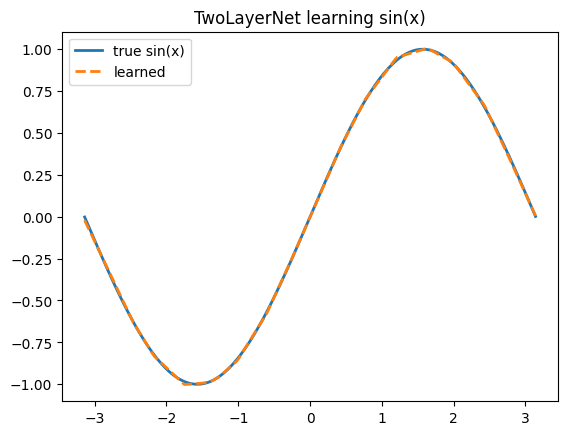

In [13]:
# Data — learning y = sin(x)
X = torch.linspace(-3.14, 3.14, 200).unsqueeze(1)
y = torch.sin(X)

model = TwoLayerNet(1, 32, 1)   # in_f=1, hidden_f=32, out_f=1
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

# Plot predictions vs true sine wave
import matplotlib.pyplot as plt

with torch.no_grad():
    y_pred = model(X)

plt.plot(X.numpy(), y.numpy(), label='true sin(x)', linewidth=2)
plt.plot(X.numpy(), y_pred.numpy(), label='learned', linestyle='--', linewidth=2)
plt.legend()
plt.title("TwoLayerNet learning sin(x)")
plt.show()